# char_05 — Addis against unburned feedstock specifically

## Purpose

`char_03` treated "unburned" as one class of 24 spectra and asked a binary question,
which the data could not answer: Addis sat off the burned/unburned axis entirely. That
result pooled six chemically very different raw materials — rice husk is a silica
accumulator, pine bark is lignin-rich, barley straw and miscanthus are grasses — and
pooling them may have hidden the thing worth looking at.

This notebook takes the unburned material seriously as **six separate reference
materials** and asks the narrower question:

> Is any specific raw biomass a good analogue for Addis filter spectra, and is unburned
> material a better or worse analogue than char?

There is a concrete reason to ask. In `char_04`'s label-free clustering, the only
charcoal-archive spectra that landed in the Addis cluster were McCall **raw feedstock** —
not char. That is a lead, and this notebook follows it.

## The reference material

| | |
|---|---|
| Source | McCall multi-feedstock (18 spectra) + McCall barley (6) — the only unburned material in the archive |
| Feedstocks | barley straw, chestnut wood, eucalyptus bark, miscanthus grass, pine bark, rice husk |
| Replicates | 3 per feedstock (6 for barley straw) |
| Preparation | bulk material, thickness-normalized ATR — **not** deposited on a filter |

24 spectra from one laboratory is a thin reference and it bounds everything below.
The comparison is also blind under 1430 cm⁻¹, which removes the C–O fingerprint where
raw biomass is most distinctive — for rice husk it also removes the Si–O band that makes
that feedstock identifiable at all.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    ramp_score, band_area, BANDS, ADDIS_USABLE,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char05")
TABLE_DIR = Path("output/tables/char05")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

# Preprocessing provenance, stamped on every figure (see char_02 §0 for why this matters).
ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   McCall: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


GRID_WIDE = np.arange(650.0, 3500.0 + 1e-9, 2.0)    # everything McCall measured
GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)        # where Addis can be compared

## Load

In [2]:
sets = load_all()
mc_meta = pd.concat(
    [sets["mccall_multi"].meta.assign(collection="McCall 6-feedstock"),
     sets["mccall_barley"].meta.assign(collection="McCall barley")],
    ignore_index=True,
)
raw_wide = np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID_WIDE),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID_WIDE),
])
raw_narrow = np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID),
])
X_mc_wide = snv(detrend(raw_wide, GRID_WIDE))
X_mc = snv(detrend(raw_narrow, GRID))
# Companion (unit-area) forms for the overlay figures; statistics stay on SNV.
X_mc_wide_s = shape_norm(detrend(raw_wide, GRID_WIDE), GRID_WIDE)
X_mc_s = shape_norm(detrend(raw_narrow, GRID), GRID)

unburned = (mc_meta["temp_c"] == 0).to_numpy()
char = (mc_meta["temp_c"] > 0).to_numpy()
FEEDSTOCKS = sorted(mc_meta.loc[unburned, "species"].unique())

etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)

print(f"unburned feedstock spectra: {unburned.sum()} across {len(FEEDSTOCKS)} materials")
display(mc_meta.loc[unburned].groupby("species").size().rename("spectra").to_frame())
print(f"McCall char spectra (for contrast): {char.sum()}")
print(f"Addis filters: {X_addis.shape[0]}")
print(f"\nramp scores — Addis {ramp_score(X_addis, GRID):+.3f}, "
      f"McCall {ramp_score(X_mc, GRID):+.3f}  (0 = no residual slope)")

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
unburned feedstock spectra: 24 across 6 materials


,spectra
species,
barley straw,9
chestnut wood,3
eucalyptus bark,3
miscanthus grass,3
pine bark,3
rice husk,3


McCall char spectra (for contrast): 216
Addis filters: 239

ramp scores — Addis -0.000, McCall +0.000  (0 = no residual slope)


## 1. The six raw materials are not one class

Before comparing anything to Addis, it is worth seeing how different the unburned
feedstocks are from each other. `char_03` averaged all six into a single "unburned"
mean; if they disagree among themselves as much as they disagree with char, that
average was not describing a real material.

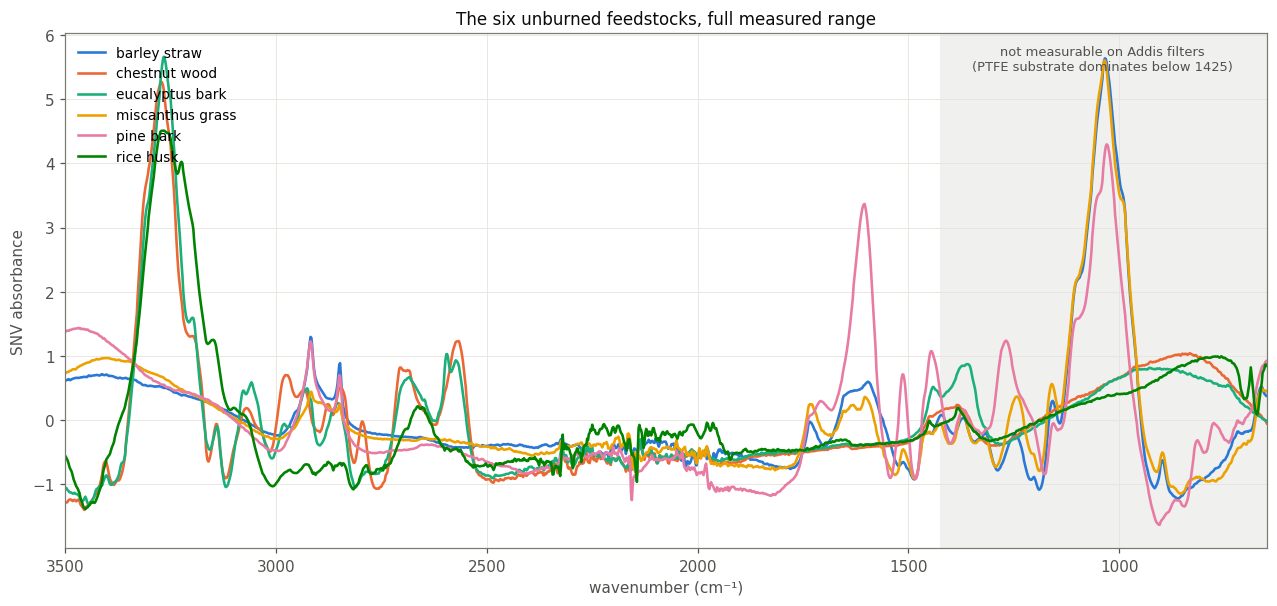

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 5.4), constrained_layout=True)
for i, sp in enumerate(FEEDSTOCKS):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID_WIDE, X_mc_wide[m].mean(0), color=SERIES[i], lw=1.7, label=sp)
ax.axvspan(GRID_WIDE.min(), ADDIS_USABLE[0], color=MUTED, alpha=0.16, lw=0, zorder=0)
ax.annotate("not measurable on Addis filters\n(PTFE substrate dominates below 1425)",
            xy=(1040, ax.get_ylim()[1]), xytext=(0, -8), textcoords="offset points",
            ha="center", va="top", fontsize=8.5, color=INK2)
ax.set_xlim(GRID_WIDE.max(), GRID_WIDE.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("The six unburned feedstocks, full measured range", color=INK)
ax.legend(fontsize=9, loc="upper left")
fig.savefig(PLOT_DIR / "01_feedstocks_full_range.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same six feedstocks with unit-area scaling instead of SNV,
so the curves read as band intensity. Statistics are unaffected.

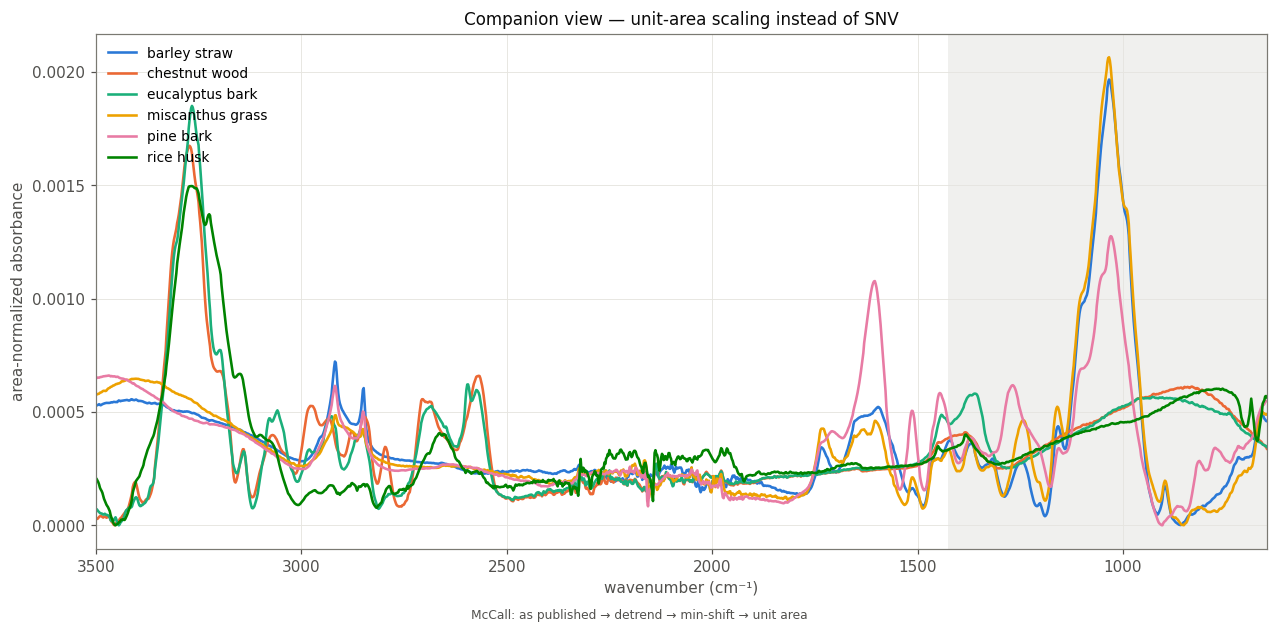

between-feedstock similarity (mean pairwise r of the 6 feedstock means):
  full range   650–3500 : 0.459
  Addis window 1430–3500: 0.455

The six raw feedstocks correlate with each other at only r ≈ 0.46 — they are genuinely different materials, not one class,
and cropping to the Addis window barely changes that (0.46). Pooling them into a single 'unburned' mean, as char_03 did,
averages over real chemistry.


In [4]:
fig, ax = plt.subplots(figsize=(11.5, 5.4), constrained_layout=True)
for i, sp in enumerate(FEEDSTOCKS):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID_WIDE, X_mc_wide_s[m].mean(0), color=SERIES[i], lw=1.7, label=sp)
ax.axvspan(GRID_WIDE.min(), ADDIS_USABLE[0], color=MUTED, alpha=0.16, lw=0, zorder=0)
ax.set_xlim(GRID_WIDE.max(), GRID_WIDE.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig, "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "01b_feedstocks_shape.png", dpi=160, bbox_inches="tight")
plt.show()

# How much of their mutual distinctiveness survives the crop to the Addis window?
def pairwise_r(X):
    Z = (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
    R = (Z @ Z.T) / X.shape[1]
    iu = np.triu_indices(len(X), 1)
    return R[iu]


means_wide = np.vstack([X_mc_wide[unburned & (mc_meta["species"] == sp).to_numpy()].mean(0)
                        for sp in FEEDSTOCKS])
means_narrow = np.vstack([X_mc[unburned & (mc_meta["species"] == sp).to_numpy()].mean(0)
                          for sp in FEEDSTOCKS])
r_wide, r_narrow = pairwise_r(means_wide).mean(), pairwise_r(means_narrow).mean()
print("between-feedstock similarity (mean pairwise r of the 6 feedstock means):")
print(f"  full range   650–3500 : {r_wide:.3f}")
print(f"  Addis window 1430–3500: {r_narrow:.3f}")
print(f"\nThe six raw feedstocks correlate with each other at only r ≈ {r_wide:.2f} — they "
      "are genuinely different materials, not one class,\nand cropping to the Addis window "
      f"barely changes that ({r_narrow:.2f}). Pooling them into a single 'unburned' mean, "
      "as char_03 did,\naverages over real chemistry.")

## 2. Addis against each unburned feedstock

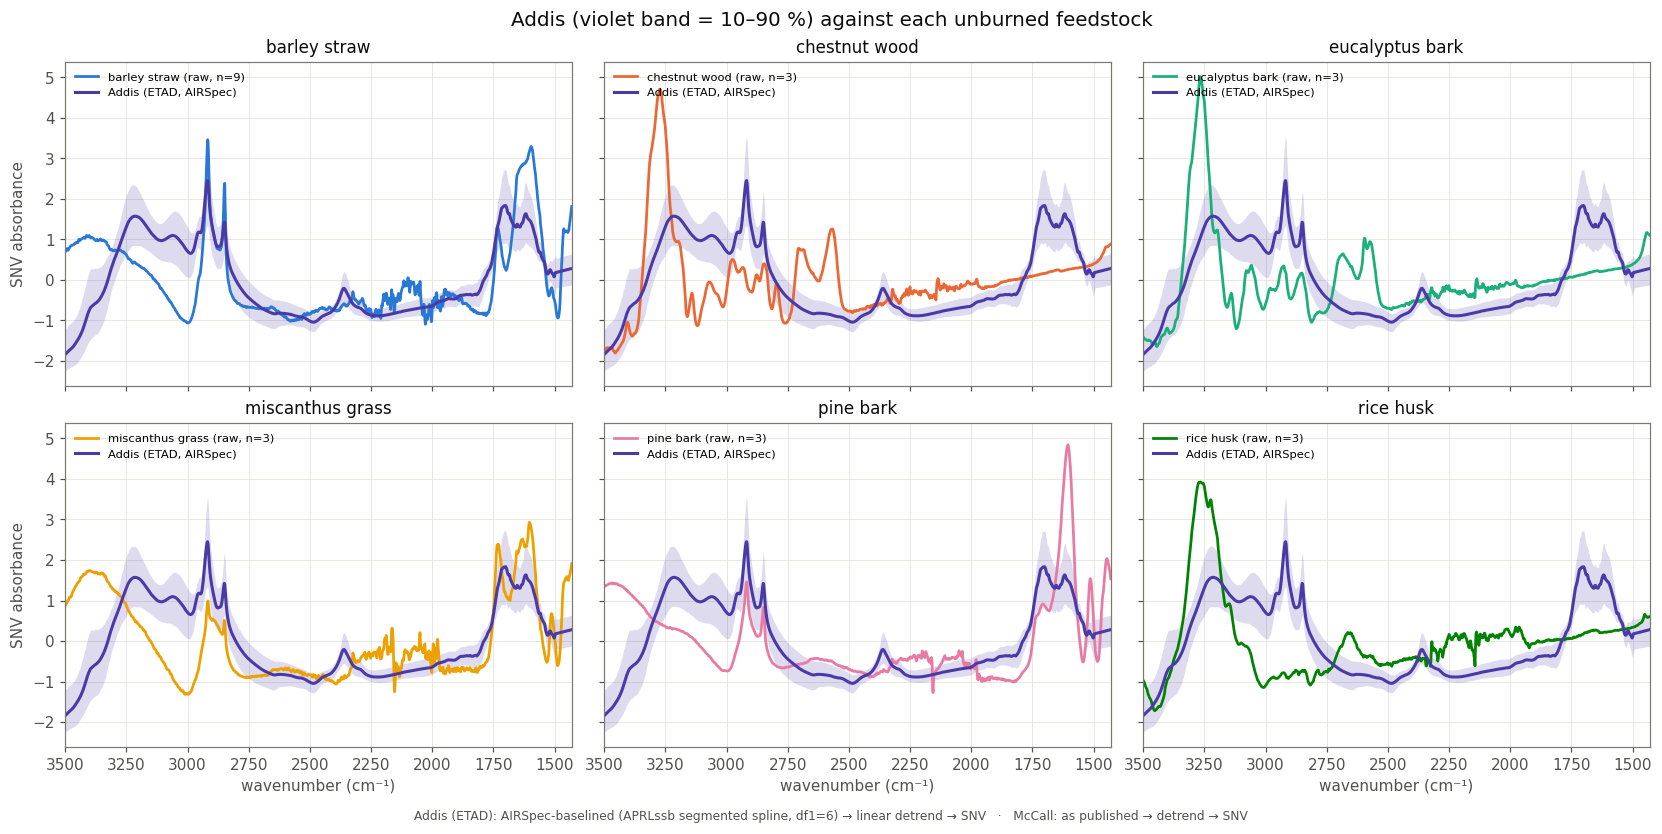

In [5]:
addis_mean = X_addis.mean(0)
addis_lo, addis_hi = np.percentile(X_addis, [10, 90], axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, (i, sp) in zip(axes.ravel(), enumerate(FEEDSTOCKS)):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID, X_mc[m].mean(0), color=SERIES[i], lw=1.8, label=f"{sp} (raw, n={m.sum()})")
    ax.fill_between(GRID, addis_lo, addis_hi, color=ADDIS_COLOR, alpha=0.18, lw=0)
    ax.plot(GRID, addis_mean, color=ADDIS_COLOR, lw=2.0, label="Addis (ETAD, AIRSpec)")
    ax.set_xlim(GRID.max(), GRID.min())
    ax.set_title(sp, color=INK)
    ax.legend(fontsize=7.5, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("SNV absorbance", color=INK2)
fig.suptitle("Addis (violet band = 10–90 %) against each unburned feedstock",
             fontsize=13, color=INK)
stamp(fig)
fig.savefig(PLOT_DIR / "02_addis_vs_each_feedstock.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same comparison in unit-area units, the Addis side
AIRSpec-baselined as everywhere in this folder.

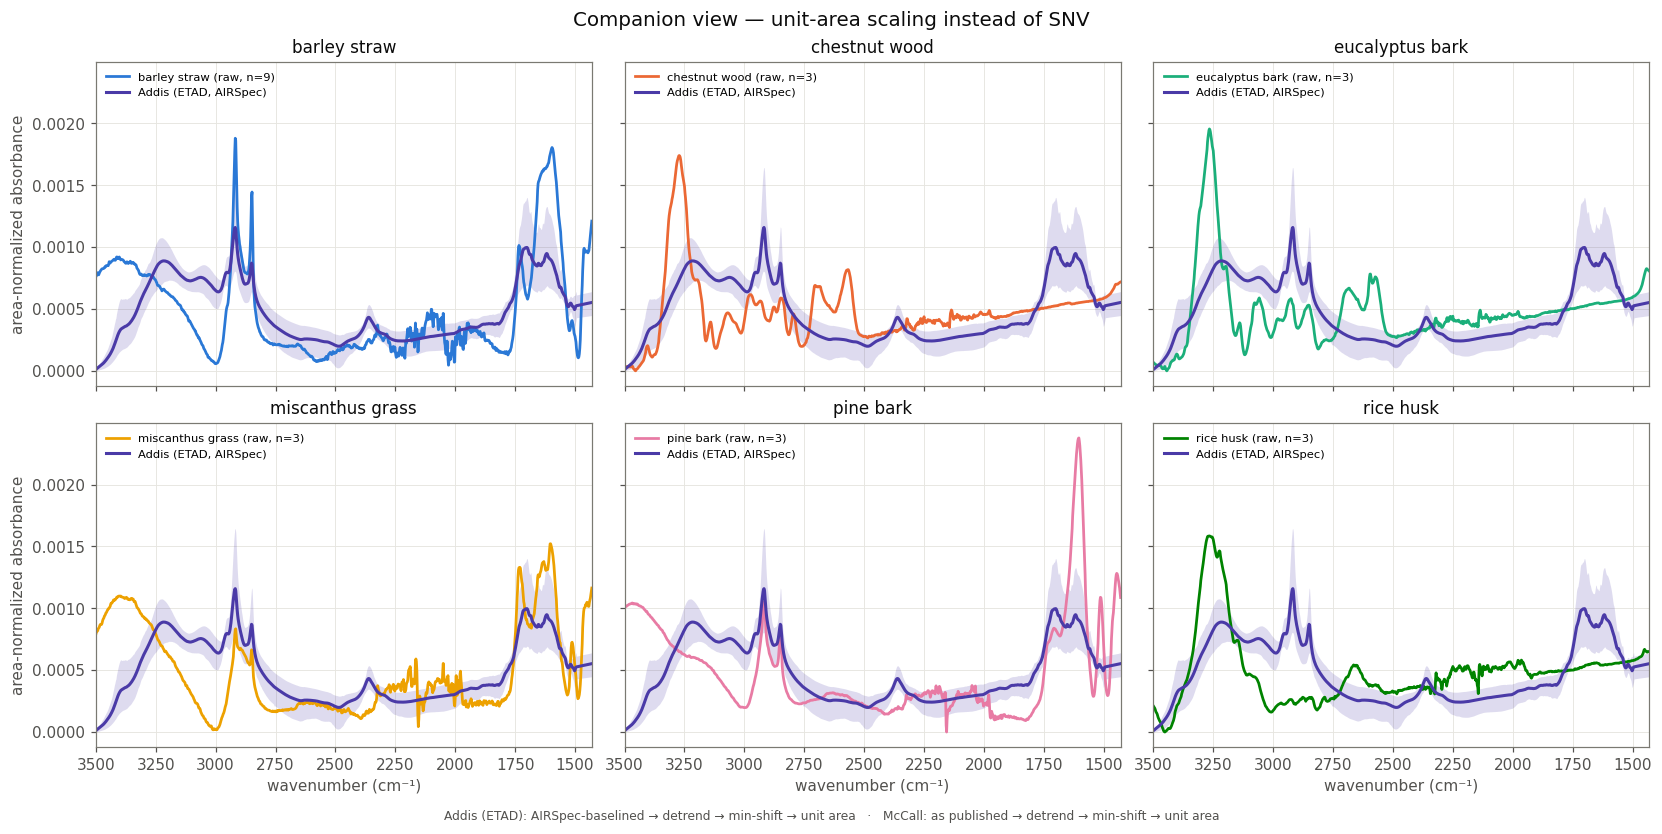

In [6]:
addis_mean_s = X_addis_shape.mean(0)
addis_lo_s, addis_hi_s = np.percentile(X_addis_shape, [10, 90], axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), constrained_layout=True,
                         sharex=True, sharey=True)
for ax, (i, sp) in zip(axes.ravel(), enumerate(FEEDSTOCKS)):
    m = unburned & (mc_meta["species"] == sp).to_numpy()
    ax.plot(GRID, X_mc_s[m].mean(0), color=SERIES[i], lw=1.8,
            label=f"{sp} (raw, n={m.sum()})")
    ax.fill_between(GRID, addis_lo_s, addis_hi_s, color=ADDIS_COLOR, alpha=0.18, lw=0)
    ax.plot(GRID, addis_mean_s, color=ADDIS_COLOR, lw=2.0, label="Addis (ETAD, AIRSpec)")
    ax.set_xlim(GRID.max(), GRID.min())
    ax.set_title(sp, color=INK)
    ax.legend(fontsize=7.5, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
for ax in axes[:, 0]:
    ax.set_ylabel("area-normalized absorbance", color=INK2)
fig.suptitle("Companion view — unit-area scaling instead of SNV", fontsize=13, color=INK)
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "02b_addis_vs_each_feedstock_shape.png", dpi=160,
            bbox_inches="tight")
plt.show()

## 3. Which analogue is actually closest — raw biomass or char?

Correlation of every Addis filter against every McCall reference spectrum, grouped by
what that reference is. The comparison that matters is unburned feedstock versus char:
`char_02` already established that Addis matches the *whole* charcoal archive at
r ≈ 0.78, and the question here is whether raw material does better.

In [7]:
def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


Za, Zm = zrows(X_addis), zrows(X_mc)
R = (Za @ Zm.T) / GRID.size          # (239 Addis, 240 McCall)

groups = {}
for sp in FEEDSTOCKS:
    groups[f"{sp} (raw)"] = unburned & (mc_meta["species"] == sp).to_numpy()
groups["— all unburned —"] = unburned
groups["— all char (150–700 °C) —"] = char

# "best match among n references" grows mechanically with n, so a mean-based statistic is
# reported beside it. The n-bias runs *against* the unburned class here (24 references vs
# 216 for char), which makes the max-based comparison conservative in its favour.
rows = []
for name, m in groups.items():
    best = R[:, m].max(axis=1)
    rows.append({"reference": name, "n ref spectra": int(m.sum()),
                 "median best r": np.median(best),
                 "median mean r": np.median(R[:, m].mean(axis=1)),
                 "10th pct (best)": np.percentile(best, 10),
                 "90th pct (best)": np.percentile(best, 90)})
match_table = pd.DataFrame(rows).set_index("reference").round(3)
display(match_table)
print("`median best r` is the max over that group's references, so it rises with the "
      "reference count;\n`median mean r` does not. Compare feedstocks on the second column "
      "— barley straw carries 9\nreplicates against 3 for the others.")
match_table.to_csv(TABLE_DIR / "addis_vs_unburned_match.csv")

best_unb = R[:, unburned].max(axis=1)
best_char = R[:, char].max(axis=1)
print(f"\nAddis filters better matched by raw feedstock than by any char: "
      f"{(best_unb > best_char).mean():.0%}")
winner = np.array(FEEDSTOCKS)[
    np.array([R[:, unburned & (mc_meta['species'] == sp).to_numpy()].max(axis=1)
              for sp in FEEDSTOCKS]).argmax(axis=0)]
print("\nclosest unburned feedstock per Addis filter:")
display(pd.Series(winner).value_counts().rename("filters").to_frame())

,n ref spectra,median best r,median mean r,10th pct (best),90th pct (best)
reference,,,,,
barley straw (raw),9,0.560,0.486,0.316,0.766
chestnut wood (raw),3,0.386,0.365,0.294,0.504
eucalyptus bark (raw),3,0.365,0.354,0.255,0.509
miscanthus grass (raw),3,0.374,0.346,0.117,0.630
pine bark (raw),3,0.395,0.378,0.183,0.617
rice husk (raw),3,0.355,0.335,0.189,0.564
— all unburned —,24,0.585,0.415,0.418,0.766
— all char (150–700 °C) —,216,0.553,0.278,0.331,0.760


`median best r` is the max over that group's references, so it rises with the reference count;
`median mean r` does not. Compare feedstocks on the second column — barley straw carries 9
replicates against 3 for the others.

Addis filters better matched by raw feedstock than by any char: 85%

closest unburned feedstock per Addis filter:


,filters
barley straw,159
rice husk,62
chestnut wood,18


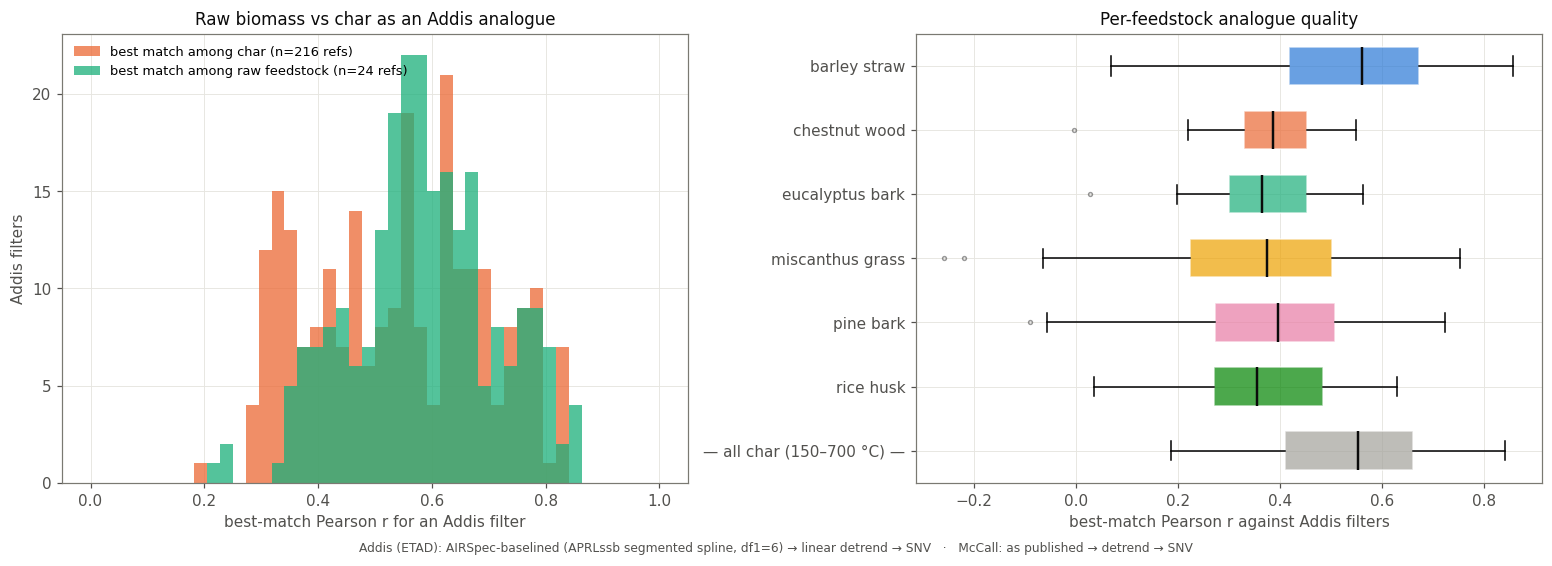

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

ax = axes[0]
bins = np.linspace(0, 1, 45)
ax.hist(best_char, bins=bins, color=SERIES[1], alpha=0.75,
        label=f"best match among char (n={int(char.sum())} refs)")
ax.hist(best_unb, bins=bins, color=SERIES[2], alpha=0.75,
        label=f"best match among raw feedstock (n={int(unburned.sum())} refs)")
ax.set_xlabel("best-match Pearson r for an Addis filter", color=INK2)
ax.set_ylabel("Addis filters", color=INK2)
ax.set_title("Raw biomass vs char as an Addis analogue", color=INK)
ax.legend(fontsize=8.5)

ax = axes[1]
order = [f"{sp} (raw)" for sp in FEEDSTOCKS] + ["— all char (150–700 °C) —"]
vals = [R[:, groups[o]].max(axis=1) for o in order]
cols = SERIES[:len(FEEDSTOCKS)] + [MUTED]
bp = ax.boxplot(vals, vert=False, tick_labels=[o.replace(" (raw)", "") for o in order],
                patch_artist=True, widths=0.6,
                medianprops=dict(color=INK, lw=1.6), flierprops=dict(ms=2.5, alpha=0.4))
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(c); patch.set_alpha(0.7); patch.set_edgecolor("white")
ax.set_xlabel("best-match Pearson r against Addis filters", color=INK2)
ax.set_title("Per-feedstock analogue quality", color=INK)
ax.invert_yaxis()

stamp(fig)
fig.savefig(PLOT_DIR / "03_match_quality.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Where the residual disagreement lives

The difference spectrum, Addis minus the closest unburned feedstock mean. Whatever is
left over is what raw biomass does *not* explain about an Addis filter.

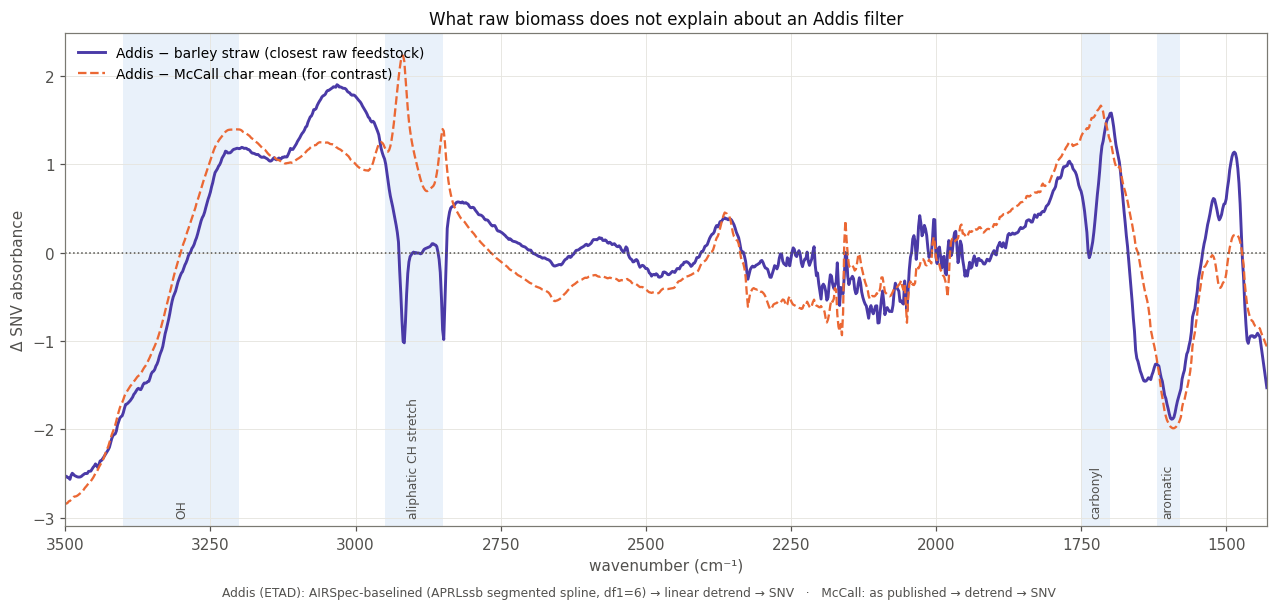

,Addis,barley straw (raw),all unburned,all char
OH / NH stretch,0.46,0.75,1.17,0.50
aromatic CH stretch,1.07,-0.69,-0.50,-0.16
aliphatic CH stretch,1.37,1.33,0.50,0.12
carbonyl C=O,1.43,0.70,0.60,-0.05
aromatic C=C,1.42,3.04,2.05,3.19


In [9]:
best_sp = match_table.loc[[f"{sp} (raw)" for sp in FEEDSTOCKS], "median mean r"].idxmax()
best_sp_name = best_sp.replace(" (raw)", "")
ref_mean = X_mc[unburned & (mc_meta["species"] == best_sp_name).to_numpy()].mean(0)
char_mean = X_mc[char].mean(0)

fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
ax.plot(GRID, addis_mean - ref_mean, color=ADDIS_COLOR, lw=1.9,
        label=f"Addis − {best_sp_name} (closest raw feedstock)")
ax.plot(GRID, addis_mean - char_mean, color=SERIES[1], lw=1.5, ls="--",
        label="Addis − McCall char mean (for contrast)")
ax.axhline(0, color=INK2, lw=1, ls=":")
for name in ["OH / NH stretch", "aliphatic CH stretch", "carbonyl C=O", "aromatic C=C"]:
    lo, hi = BANDS[name]
    ax.axvspan(lo, hi, color=SERIES[0], alpha=0.10, lw=0, zorder=0)
    ax.annotate(name.split(" /")[0].split(" C=")[0], xy=((lo + hi) / 2, ax.get_ylim()[0]),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2, rotation=90)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("Δ SNV absorbance", color=INK2)
ax.set_title("What raw biomass does not explain about an Addis filter", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "04_residual.png", dpi=160, bbox_inches="tight")
plt.show()

# Band-level accounting
band_tab = pd.DataFrame({
    "Addis": {n: band_area(X_addis, GRID, w).mean() for n, w in BANDS.items()
              if w[0] >= GRID.min() and w[1] <= GRID.max()},
    f"{best_sp_name} (raw)": {
        n: band_area(X_mc[unburned & (mc_meta["species"] == best_sp_name).to_numpy()],
                     GRID, w).mean()
        for n, w in BANDS.items() if w[0] >= GRID.min() and w[1] <= GRID.max()},
    "all unburned": {n: band_area(X_mc[unburned], GRID, w).mean() for n, w in BANDS.items()
                     if w[0] >= GRID.min() and w[1] <= GRID.max()},
    "all char": {n: band_area(X_mc[char], GRID, w).mean() for n, w in BANDS.items()
                 if w[0] >= GRID.min() and w[1] <= GRID.max()},
}).round(2)
display(band_tab)
band_tab.to_csv(TABLE_DIR / "band_levels.csv")

## 5. Does it vary by season?

,filters,best r vs raw feedstock,best r vs char,share better matched by raw
season,,,,
Dry Season,105,0.531,0.406,0.933
Belg Rainy Season,61,0.684,0.686,0.738
Kiremt Rainy Season,73,0.616,0.615,0.822


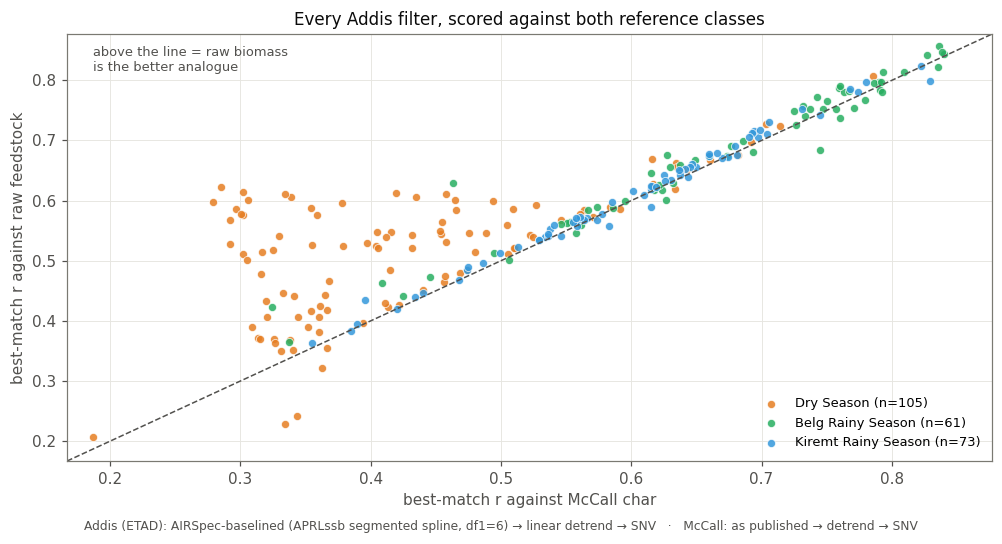

In [10]:
season_rows = []
for season in SEASON_COLORS:
    m = (etad_meta["season_label"] == season).to_numpy()
    if not m.any():
        continue
    season_rows.append({
        "season": season, "filters": int(m.sum()),
        "best r vs raw feedstock": np.median(best_unb[m]),
        "best r vs char": np.median(best_char[m]),
        "share better matched by raw": (best_unb[m] > best_char[m]).mean(),
    })
season_tab = pd.DataFrame(season_rows).set_index("season").round(3)
display(season_tab)
season_tab.to_csv(TABLE_DIR / "by_season.csv")

fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
for season, color in SEASON_COLORS.items():
    m = (etad_meta["season_label"] == season).to_numpy()
    if m.any():
        ax.scatter(best_char[m], best_unb[m], s=28, c=color, edgecolor="white",
                   linewidth=0.5, alpha=0.85, label=f"{season} (n={m.sum()})")
lims = [min(best_char.min(), best_unb.min()) - 0.02,
        max(best_char.max(), best_unb.max()) + 0.02]
ax.plot(lims, lims, color=INK2, lw=1, ls="--", zorder=1)
ax.annotate("above the line = raw biomass\nis the better analogue",
            xy=(lims[0] + 0.02, lims[1] - 0.02), fontsize=8.5, color=INK2, va="top")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("best-match r against McCall char", color=INK2)
ax.set_ylabel("best-match r against raw feedstock", color=INK2)
ax.set_title("Every Addis filter, scored against both reference classes", color=INK)
ax.legend(fontsize=8.5, loc="lower right")
stamp(fig)
fig.savefig(PLOT_DIR / "05_by_season.png", dpi=160, bbox_inches="tight")
plt.show()

## Takeaways

- **Splitting "unburned" into six materials was the right call.** The six raw feedstocks
  correlate with one another at only **r ≈ 0.46** — they are genuinely different
  materials, and cropping to the Addis window barely changes that (0.46 → 0.46). The
  single pooled "unburned" mean `char_03` used was averaging over real chemistry.
- **Within McCall, raw biomass is the better analogue for Addis than char is —
  decisively.** **85 %** of Addis filters match some raw feedstock better than any of the
  216 char spectra. On the count-unbiased statistic the gap is wide: median mean r
  **0.415** for unburned versus **0.278** for char. And the reference-count bias runs
  *against* this result — char has nine times more reference spectra and still loses —
  so the comparison is conservative in raw biomass's favour.
- **Barley straw is the closest single material** (median mean r **0.486**, against
  0.34–0.38 for the other five), and it is the only feedstock that stands clear of the
  pack. It is also the one with extra replicates, so this is stated on the
  count-unbiased column, not the max-based one.
- **But do not read this as "Addis is unburned biomass."** Two things forbid it. First,
  the absolute agreement is poor: r ≈ 0.5 is nowhere near the r ≈ 0.99 that genuinely
  like materials achieve. Second, and more important, **`char_02`'s full 3,924-spectrum
  charcoal library matched Addis at r ≈ 0.78** — better than anything in this notebook.
  The honest statement is narrow: *within the McCall collection*, raw feedstock is a
  closer analogue than McCall's own char. McCall's char is simply a poor reference for
  Addis, not evidence that Addis is unburned.
- **The residual says what raw biomass cannot explain.** Aliphatic C–H is essentially
  matched (Addis 1.37 vs barley straw 1.33) — that band is fully accounted for by raw
  biomass. What is not: Addis carries far more carbonyl (1.43 vs 0.70) and aromatic C–H
  (1.07 vs −0.69) and far less aromatic C=C (1.42 vs 3.04). Excess oxygenation with
  suppressed aromatic C=C is the signature of an aged, oxidized organic aerosol rather
  than of fresh plant material or of char.
- **The Dry season is where this is strongest, and it is the interesting result.** In the
  Dry season (Oct–Feb) **93 %** of filters are better matched by raw biomass, and the
  match to char is much weaker (median r 0.406 versus 0.53 for raw). In Belg and Kiremt
  the two references are effectively tied (0.68 vs 0.69). So Addis filters are least
  char-like precisely in the dry months — the same ordering `char_02` found against the
  full charcoal library, arrived at through a different reference set.

**Caveats.** 24 unburned spectra from one laboratory, three replicates for five of the
six feedstocks, measured as bulk ATR rather than on filters. The window excludes the C–O
fingerprint — and for rice husk it removes the Si–O band that identifies that feedstock
at all, so its poor showing here is partly a measurement-window artifact rather than a
chemical result. Nothing here separates "raw biomass in the aerosol" from "aged organic
aerosol that happens to resemble raw biomass in four bands".